## Setup

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

torch.cuda.is_available()

False

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
path = "/content/drive/MyDrive/ML_project/"

## Data Loading & Preprocessing

In this step I load the data and preprocess it:
- keeping only english samples
- removing samples with potential noise (sometimes the post may contain information that makes it obvious it's AI-generated, for example it explicitly says "as an assistant...")
- separating Gemini-generated samples for use as out-of-distribution test data
- renaming source to only the platform name

In [10]:
from sklearn.model_selection import train_test_split

df = pd.read_csv(f"{path}/data/multisocial_anonymized.csv")
df = df[df["language"] == "en"]
df = df[df["potential_noise"] != 1]
df["source"] = df["source"].str.replace("multisocial_", "", regex=False)

In [11]:
df.reset_index()

,index,text,label,multi_label,split,language,length,source,potential_noise
0,1,The breathtaking picture shared by [USER] is t...,1,v5-Eagle-7B-HF,train,en,10,twitter,0
1,5,I'm here to help you.,1,aya-101,train,en,5,whatsapp,0
2,18,"The concert by the band "" Triângulo "" has come...",1,gpt-3.5-turbo-0125,train,en,13,gab,0
3,19,The infectiously hilarious duo of Jonah Hill a...,1,gemini,train,en,72,twitter,0
4,23,It seemed to me that you might be relocating t...,1,Mistral-7B-Instruct-v0.2,train,en,11,telegram,0
...,...,...,...,...,...,...,...,...,...
48255,472036,Step 1: Move towards the nearest exit door.Ste...,1,v5-Eagle-7B-HF,train,en,24,discord,0
48256,472041,Greetings to all those with radiant hair as da...,1,Mistral-7B-Instruct-v0.2,train,en,12,discord,0
48257,472075,I love everything about both.,1,aya-101,train,en,5,telegram,0
48258,472086,"""If you think that's unacceptable, you should ...",1,vicuna-13b,train,en,11,discord,0


Previewing class count (AI vs human generated), showing this is an imbalanced dataset.

In [12]:
df["label"].value_counts()

,count
label,
1,41974
0,6286


Previewing the number of samples per platform (pretty balanced!)

In [13]:
df.source.value_counts()

,count
source,
twitter,9841
gab,9725
telegram,9655
discord,9532
whatsapp,9507


### Processing Length of posts

An objective of the study is to analyze whether fine-tuning on conditional samples increases the performance of detecting AI-generated output across posts of varying lengths. I first plot the distribution of post lengths and then divide the posts into 3 different bins.

count    48260.000000
mean        28.034231
std         35.762879
min          3.000000
33%         10.000000
50%         15.000000
66%         23.000000
max        200.000000
Name: length, dtype: float64


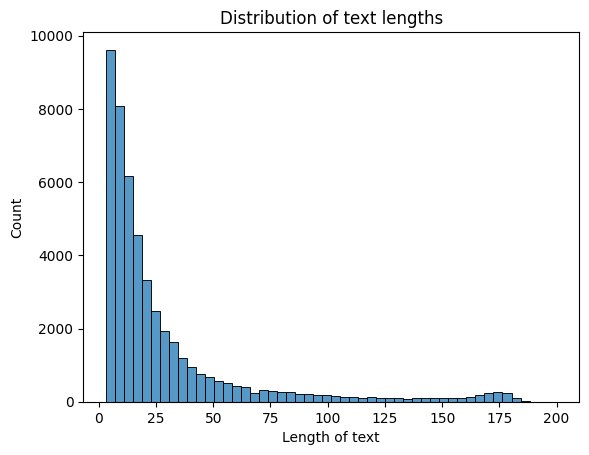

In [14]:
print(df["length"].describe([0.33,0.66])) # computing 33rd and 66th percentiles to define length bins (exactly split in 3 equal parts)
# histgoram of length
sns.histplot(df["length"], bins=50)
plt.xlabel("Length of text")
plt.ylabel("Count")
plt.title("Distribution of text lengths")
plt.show()

In [15]:

def make_length_bin(length):
    if length <= 10:
        return "short"
    elif length <= 23:
        return "medium"
    else:
        return "long"

df["length_bin"] = df["length"].apply(make_length_bin)
df["length_bin"].value_counts()

,count
length_bin,
short,17680
long,15847
medium,14733


like the reference paper, and following ML best practice, I keep one ai-generated model posts (gemini) out of training samples and keeping it only for the test

In [16]:
gemini_mask = df["multi_label"].astype(str).str.contains("gemini")
df_gemini = df[gemini_mask].copy()
df_non_gemini = df[~gemini_mask].copy()

non_gemini_train_base = df_non_gemini[df_non_gemini["split"] == "train"]
non_gemini_test_base = df_non_gemini[df_non_gemini["split"] == "test"]


# dividing non-gemini train pool for training and hyperparameter tuning(val)
train_df, val_df = train_test_split(
    non_gemini_train_base,
    test_size=0.2,
    stratify=non_gemini_train_base["label"], # here I make sure the label distribution is the same in train and val since the dataset is imbalanced
    random_state=42,
)

test_df = pd.concat([non_gemini_test_base, df_gemini], ignore_index=True).reset_index(drop=True)

val_df.to_csv(f"{path}/checkpoints/val_df.csv", index=False)
test_df.to_csv(f"{path}/checkpoints/test_df.csv", index=False)

In [ ]:
print(f"Train= {len(train_df)}, Val= {len(val_df)}, Test= {len(test_df)}")

Train= 25897, Val= 6475, Test= 15888


Printing the ratio and making sure train/test/val have the same ratio of human/ai posts

In [18]:
for d in [ train_df, val_df, test_df]:
    counts = d["label"].value_counts()
    n0 = counts.get(0, 0)
    n1 = counts.get(1, 0)
    print(f"0 labels",n0, round(n0 / len(d),2))
    print(f"1 labels",n1, round(n1 / len(d),2))

0 labels 3859 0.15
1 labels 22038 0.85
0 labels 965 0.15
1 labels 5510 0.85
0 labels 1462 0.09
1 labels 14426 0.91


## Tokenizer & Special Tokens

Among the models the paper have tested, RoBERTa-large(355M)is the only english-only model. Given the limited resources I chose RoBERTa-base (125M ). For both the conditioned and unconditioned model the new tokens should be added to the vocabulary.

In [20]:
from transformers import RobertaTokenizerFast

tokenizer = RobertaTokenizerFast.from_pretrained("roberta-base")

special_tokens = ["[PLATFORM: twitter]", "[PLATFORM: discord]", "[PLATFORM: gab]", "[PLATFORM: telegram]", "[PLATFORM: whatsapp]"]
tokenizer.add_tokens(special_tokens)

tokenizer.save_pretrained(f"{path}/checkpoints/tokenizer")

('/content/drive/MyDrive/ML_project//checkpoints/tokenizer/tokenizer_config.json',
 '/content/drive/MyDrive/ML_project//checkpoints/tokenizer/tokenizer.json')

In [21]:
len(tokenizer)

50270

## Dataset Class

In [22]:
from torch.utils.data import Dataset

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=200):
        self.encodings = tokenizer(list(texts), truncation=True, padding="max_length", max_length=max_length)
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }

## Training

I am using roberta base with a randomly initalized classifier head that it must be learned during fine-tuning.
I chose epoch=3 for finetuning which should be enough for the classifier head to learn useful patterns, but is also short enough to prevent overfitting.

3 small training configs are used to find what works best on validation data:
- config 1: basic (no warmup, no weight decay)
- config 2: changing batch size and adding weight decay (compared to basic)
- config 3: adds weight decay and learning rate warmup (compared to basic)


#### Acknowledgement:
I used the code in the following links for my implementation:
- [PyTorch Training a Classifier](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html)
- [PyTorch Transfer Learning Tutorial](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)
- [Roberta-FineTuning](https://pchanda.github.io/Roberta-FineTuning-for-Classification/)

This [link](https://medium.com/@heyamit10/fine-tuning-bert-for-sentiment-analysis-a-practical-guide-f3d9c9cac236) helped in choosing parameters!


In [23]:
from copy import deepcopy
from torch.utils.data import DataLoader
from transformers import RobertaForSequenceClassification, get_linear_schedule_with_warmup

CONFIGS = [
    {
        "name": "config_1",
        "num_train_epochs": 3,
        "train_batch_size": 64,
        "eval_batch_size": 64,
        "learning_rate": 2e-5,
        "warmup_ratio": 0.0,
        "weight_decay": 0.0
    },
    {
        "name": "config_2",
        "num_train_epochs": 3,
        "train_batch_size": 16,
        "eval_batch_size": 64,
        "learning_rate": 2e-5,
        "warmup_ratio": 0.0,
        "weight_decay": 0.01
    },
    {
        "name": "config_3",
        "num_train_epochs": 3,
        "train_batch_size": 64,
        "eval_batch_size": 64,
        "learning_rate": 2e-5,
        "warmup_ratio": 0.1,
        "weight_decay": 0.01
    },
]

In [24]:
def run_eval_epoch(model, eval_loader):
    model.eval()
    loss_sum = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in eval_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            preds = torch.argmax(outputs.logits, dim=1)

            loss_sum += outputs.loss.item()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return loss_sum / max(len(eval_loader), 1), correct / max(total, 1)


In [25]:
def run_train_epoch(model, train_loader, optimizer, scheduler, cfg):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        preds = torch.argmax(outputs.logits, dim=1)

        optimizer.zero_grad(set_to_none=True)
        outputs.loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += outputs.loss.item()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if i % 50 == 0:
            print(f"Step {i}/{len(train_loader)} | Loss: {outputs.loss.item():.4f}")

    return running_loss / max(len(train_loader), 1), correct / max(total, 1)



In [26]:


def build_optimizer_and_scheduler(model, train_loader, cfg):
    """
    Create an AdamW optimizer and a linear warmup/decay scheduler.

    Args:
        model (torch.nn.Module): Model to optimize.
        train_loader (DataLoader): Training dataloader to compute total steps.
        cfg (dict): Training config containing learning rate, weight decay, warmup ratio, and number of epochs.

    Returns:
        tuple: (optimizer, scheduler)
    """
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg["learning_rate"],
        weight_decay=cfg["weight_decay"],
    )
    total_steps = len(train_loader) * cfg["num_train_epochs"]
    warmup_steps = int(total_steps * cfg["warmup_ratio"])
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )
    return optimizer, scheduler



def train_one_model(model, train_ds, eval_ds, output_dir, cfg):
    """
    Fine-tune a model for the number of epochs in cfg, tracking the best validation
    accuracy checkpoint, then save the best weights to output_dir.

    Args:
        model (torch.nn.Module): Initialized (pre-trained) model to fine-tune.
        train_ds (TextDataset): Training dataset.
        eval_ds (TextDataset): Validation dataset used for checkpoint selection.
        output_dir (str): Directory where the best model will be saved.
        cfg (dict): Training hyperparameters (epochs, batch sizes, lr, etc.).

    Returns:
        tuple[torch.nn.Module, dict]: (best_model, history) where history contains
        per-epoch train/val loss and accuracy lists.
    """
    train_loader = DataLoader(train_ds, batch_size=cfg["train_batch_size"], shuffle=True)
    eval_loader = DataLoader(eval_ds, batch_size=cfg["eval_batch_size"], shuffle=False)

    model.to(device)
    optimizer, scheduler = build_optimizer_and_scheduler(model, train_loader, cfg)

    history = {"train_loss": [], "train_accuracy": [], "val_loss": [], "val_accuracy": []}
    best_acc = -1.0
    best_state = None

    for epoch in range(cfg["num_train_epochs"]):
        train_loss, train_acc = run_train_epoch(model, train_loader, optimizer, scheduler, cfg)
        val_loss, val_acc = run_eval_epoch(model, eval_loader)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        print(
            f"Epoch {epoch + 1}/{cfg['num_train_epochs']} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
        )

        if val_acc > best_acc:
            best_acc = val_acc
            best_state = deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)
    model.save_pretrained(output_dir)
    return model, history


In [27]:

def plot_history(history, title, save_path, cfg=None):
    """
    Plot train/val loss and accuracy curves and save.

    Args:
        history (dict): Keys train_loss, val_loss, train_accuracy, val_accuracy
                        (each a list of per-epoch values).
    """
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_xlabel("Epoch")
    axes[0].set_title("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_accuracy"], label="train")
    axes[1].plot(epochs, history["val_accuracy"], label="val")
    axes[1].set_xlabel("Epoch")
    axes[1].set_title("Accuracy")
    axes[1].legend()

    fig.suptitle(title)

    if cfg is not None:
        cfg_text = "\n".join([f"{k}: {v}" for k, v in cfg.items() if k != "name"])
        fig.text(
            0.995, 0.5, cfg_text,
            ha="right", va="center", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="whitesmoke", edgecolor="gray"),
        )
        fig.tight_layout(rect=[0.0, 0.0, 0.86, 0.92])
    else:
        fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.92])

    fig.savefig(save_path, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def train_all_configs(model_name, train_ds, val_ds):
    """
    Train a fresh model for each entry in CONFIGS, select the best by val accuracy,
    and return its name.

    Args:
        model_name (str): Identifier used for checkpoint and output directories.
        train_ds (TextDataset): Training dataset.
        val_ds (TextDataset): Validation dataset (used for config selection).

    Returns:
        str: Name of the best-performing config.
    """
    cfg_val_accs = {}
    for cfg in CONFIGS:
        model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
        model.resize_token_embeddings(len(tokenizer))
        _, history = train_one_model(
            model=model,
            train_ds=train_ds,
            eval_ds=val_ds,
            output_dir=f"{path}/checkpoints/{model_name}/{cfg['name']}",
            cfg=cfg,
        )
        plot_history(
            history=history,
            title=f"{model_name} — {cfg['name']}",
            save_path=f"{path}/outputs/plots/{model_name}_{cfg['name']}_history.png",
            cfg=cfg,
        )
        cfg_val_accs[cfg["name"]] = max(history["val_accuracy"])

    best_cfg_name = max(cfg_val_accs, key=cfg_val_accs.get)
    print(f"Best config for {model_name}: {best_cfg_name} (val_acc={cfg_val_accs[best_cfg_name]:.4f})")
    return best_cfg_name


## Model A: finetuning roberta-base on original posts for classifying AI-generated posts

In [ ]:
train_ds_a = TextDataset(train_df["text"], train_df["label"], tokenizer)
val_ds_a = TextDataset(val_df["text"], val_df["label"], tokenizer)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 29021.74it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialized fro

Step 0/405 | Loss: 0.7039
Step 50/405 | Loss: 0.2699
Step 100/405 | Loss: 0.4207
Step 150/405 | Loss: 0.2835
Step 200/405 | Loss: 0.2758
Step 250/405 | Loss: 0.3347
Step 300/405 | Loss: 0.2127
Step 350/405 | Loss: 0.1420
Step 400/405 | Loss: 0.3026
Epoch 1/3 | train_loss=0.2711 | train_acc=0.8856 | val_loss=0.2351 | val_acc=0.8999
Step 0/405 | Loss: 0.2675
Step 50/405 | Loss: 0.2331
Step 100/405 | Loss: 0.1662
Step 150/405 | Loss: 0.2916
Step 200/405 | Loss: 0.2545
Step 250/405 | Loss: 0.1782
Step 300/405 | Loss: 0.1861
Step 350/405 | Loss: 0.1409
Step 400/405 | Loss: 0.2319
Epoch 2/3 | train_loss=0.2185 | train_acc=0.9076 | val_loss=0.2056 | val_acc=0.9103
Step 0/405 | Loss: 0.2417
Step 50/405 | Loss: 0.2040
Step 100/405 | Loss: 0.1292
Step 150/405 | Loss: 0.1320
Step 200/405 | Loss: 0.2233
Step 250/405 | Loss: 0.2446
Step 300/405 | Loss: 0.3610
Step 350/405 | Loss: 0.1722
Step 400/405 | Loss: 0.1471
Epoch 3/3 | train_loss=0.1947 | train_acc=0.9197 | val_loss=0.2051 | val_acc=0.9146


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.01it/s]


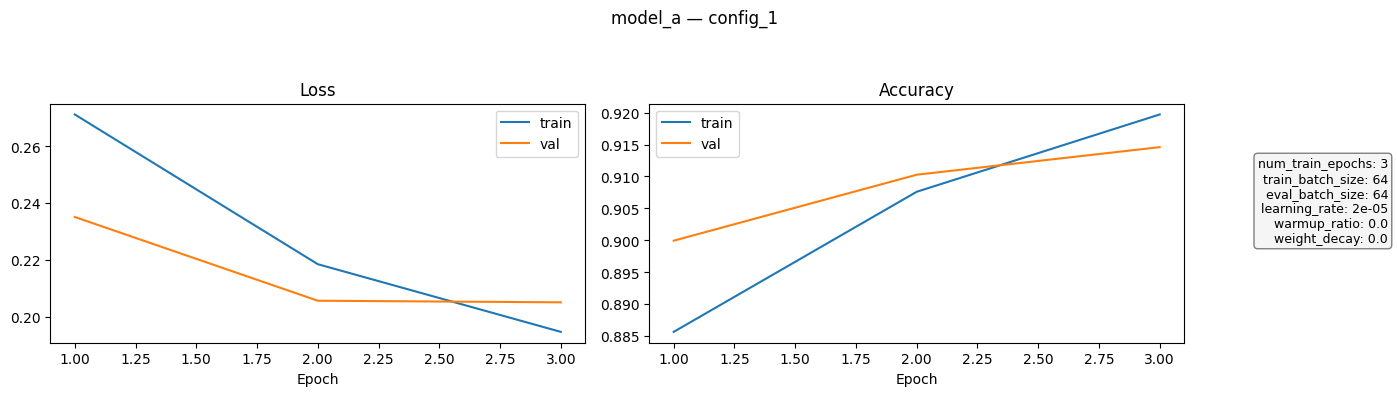

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 31827.66it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step 0/1619 | Loss: 0.6765
Step 50/1619 | Loss: 0.6112
Step 100/1619 | Loss: 0.4986
Step 150/1619 | Loss: 0.1142
Step 200/1619 | Loss: 0.2087
Step 250/1619 | Loss: 0.2942
Step 300/1619 | Loss: 0.2531
Step 350/1619 | Loss: 0.2542
Step 400/1619 | Loss: 0.1140
Step 450/1619 | Loss: 0.2447
Step 500/1619 | Loss: 0.1635
Step 550/1619 | Loss: 0.2462
Step 600/1619 | Loss: 0.1892
Step 650/1619 | Loss: 0.1152
Step 700/1619 | Loss: 0.2082
Step 750/1619 | Loss: 0.2934
Step 800/1619 | Loss: 0.3040
Step 850/1619 | Loss: 0.1571
Step 900/1619 | Loss: 0.1445
Step 950/1619 | Loss: 0.1595
Step 1000/1619 | Loss: 0.3490
Step 1050/1619 | Loss: 0.2033
Step 1100/1619 | Loss: 0.8625
Step 1150/1619 | Loss: 0.2283
Step 1200/1619 | Loss: 0.0542
Step 1250/1619 | Loss: 0.5494
Step 1300/1619 | Loss: 0.3759
Step 1350/1619 | Loss: 0.1730
Step 1400/1619 | Loss: 0.2783
Step 1450/1619 | Loss: 0.0597
Step 1500/1619 | Loss: 0.1242
Step 1550/1619 | Loss: 0.3766
Step 1600/1619 | Loss: 0.2627
Epoch 1/3 | train_loss=0.2673 | t

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.14it/s]


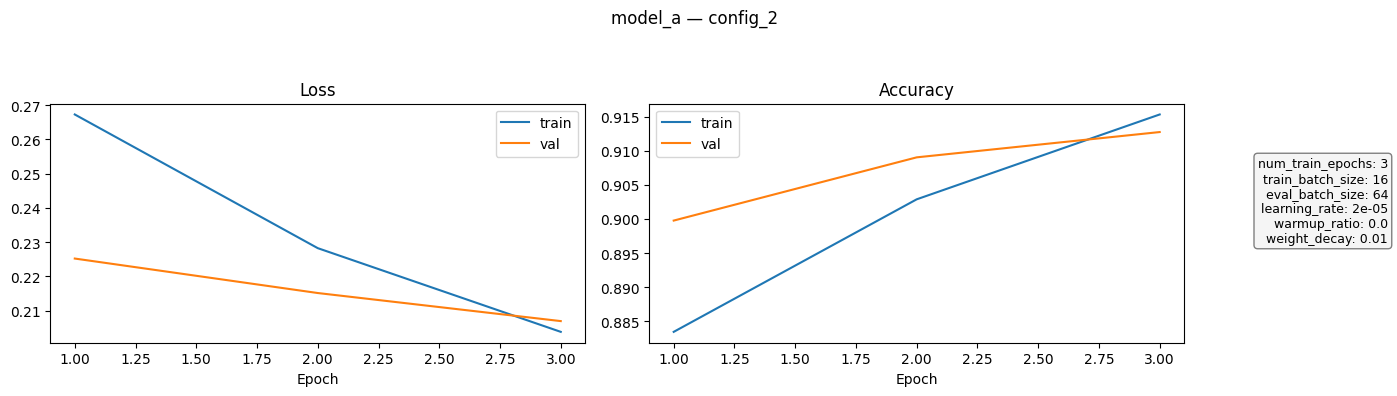

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 27888.41it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step 0/405 | Loss: 0.7115
Step 50/405 | Loss: 0.3978
Step 100/405 | Loss: 0.2029
Step 150/405 | Loss: 0.3577
Step 200/405 | Loss: 0.2411
Step 250/405 | Loss: 0.1782
Step 300/405 | Loss: 0.2422
Step 350/405 | Loss: 0.2357
Step 400/405 | Loss: 0.2203
Epoch 1/3 | train_loss=0.2983 | train_acc=0.8667 | val_loss=0.2227 | val_acc=0.9004
Step 0/405 | Loss: 0.1391
Step 50/405 | Loss: 0.3106
Step 100/405 | Loss: 0.2840
Step 150/405 | Loss: 0.1658
Step 200/405 | Loss: 0.1766
Step 250/405 | Loss: 0.1563
Step 300/405 | Loss: 0.1549
Step 350/405 | Loss: 0.1150
Step 400/405 | Loss: 0.1873
Epoch 2/3 | train_loss=0.2208 | train_acc=0.9072 | val_loss=0.2130 | val_acc=0.9118
Step 0/405 | Loss: 0.1847
Step 50/405 | Loss: 0.1905
Step 100/405 | Loss: 0.1742
Step 150/405 | Loss: 0.1768
Step 200/405 | Loss: 0.1815
Step 250/405 | Loss: 0.2308
Step 300/405 | Loss: 0.1729
Step 350/405 | Loss: 0.2566
Step 400/405 | Loss: 0.1705
Epoch 3/3 | train_loss=0.1964 | train_acc=0.9179 | val_loss=0.2005 | val_acc=0.9175


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.24it/s]


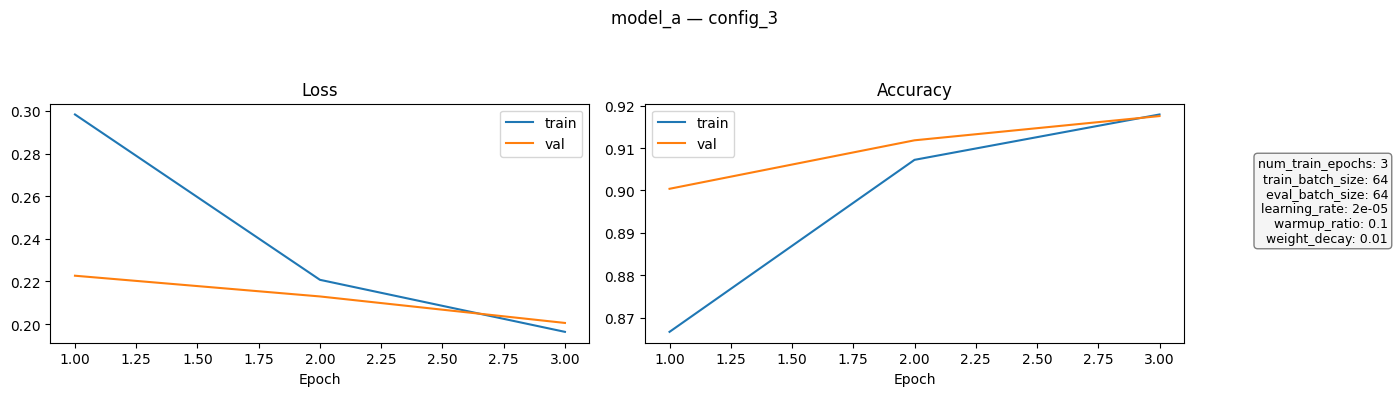


Best config for model_a: config_3 (val_acc=0.9175)


'config_3'

In [ ]:
train_all_configs("model_a", train_ds_a, val_ds_a)

## Model B (Conditioned): finetuning roberta-base on posts with platform token prepended for classifying AI-generated posts

In [ ]:
train_df_b = train_df.copy()
val_df_b = val_df.copy()
test_df_b = test_df.copy()
train_df_b["text"] = train_df_b.apply(lambda r: f"[PLATFORM: {r['source']}] {r['text']}", axis=1)
val_df_b["text"] = val_df_b.apply(lambda r: f"[PLATFORM: {r['source']}] {r['text']}", axis=1)
test_df_b["text"] = test_df_b.apply(lambda r: f"[PLATFORM: {r['source']}] {r['text']}", axis=1)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 29963.66it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialized fro

Step 0/405 | Loss: 0.7543
Step 50/405 | Loss: 0.3130
Step 100/405 | Loss: 0.3151
Step 150/405 | Loss: 0.2574
Step 200/405 | Loss: 0.2167
Step 250/405 | Loss: 0.2546
Step 300/405 | Loss: 0.2537
Step 350/405 | Loss: 0.2573
Step 400/405 | Loss: 0.3042
Epoch 1/3 | train_loss=0.2707 | train_acc=0.8826 | val_loss=0.2331 | val_acc=0.9044
Step 0/405 | Loss: 0.1496
Step 50/405 | Loss: 0.4002
Step 100/405 | Loss: 0.1454
Step 150/405 | Loss: 0.2818
Step 200/405 | Loss: 0.2220
Step 250/405 | Loss: 0.1963
Step 300/405 | Loss: 0.2351
Step 350/405 | Loss: 0.1944
Step 400/405 | Loss: 0.1998
Epoch 2/3 | train_loss=0.2199 | train_acc=0.9100 | val_loss=0.2059 | val_acc=0.9107
Step 0/405 | Loss: 0.2228
Step 50/405 | Loss: 0.1456
Step 100/405 | Loss: 0.2257
Step 150/405 | Loss: 0.1844
Step 200/405 | Loss: 0.2226
Step 250/405 | Loss: 0.1455
Step 300/405 | Loss: 0.1896
Step 350/405 | Loss: 0.2820
Step 400/405 | Loss: 0.3127
Epoch 3/3 | train_loss=0.1960 | train_acc=0.9191 | val_loss=0.2060 | val_acc=0.9157


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.12it/s]


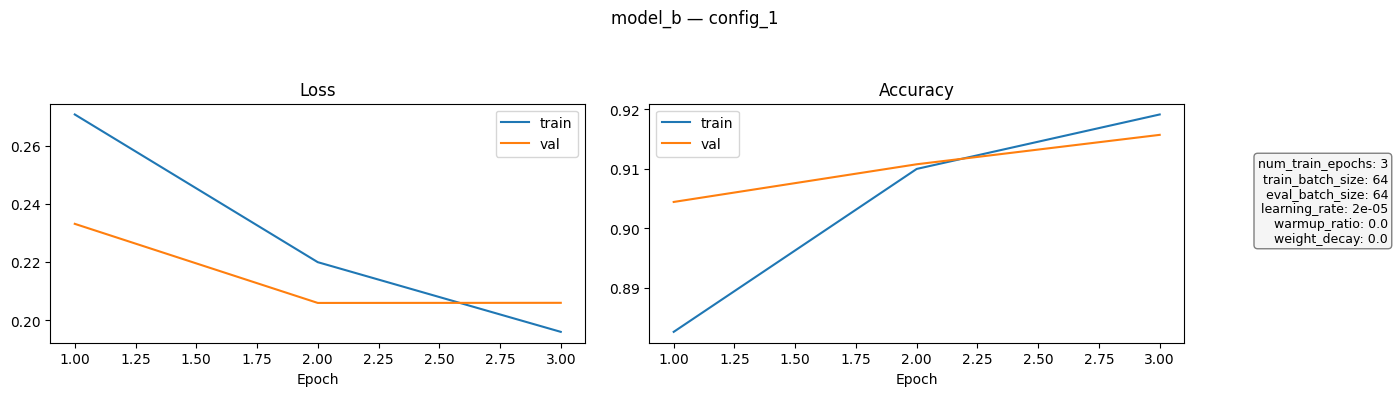

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 32932.56it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step 0/1619 | Loss: 0.6822
Step 50/1619 | Loss: 0.2464
Step 100/1619 | Loss: 0.2454
Step 150/1619 | Loss: 0.5991
Step 200/1619 | Loss: 0.3749
Step 250/1619 | Loss: 0.2417
Step 300/1619 | Loss: 0.0967
Step 350/1619 | Loss: 0.4652
Step 400/1619 | Loss: 0.1927
Step 450/1619 | Loss: 0.4800
Step 500/1619 | Loss: 0.1892
Step 550/1619 | Loss: 0.2678
Step 600/1619 | Loss: 0.2200
Step 650/1619 | Loss: 0.0800
Step 700/1619 | Loss: 0.1319
Step 750/1619 | Loss: 0.1893
Step 800/1619 | Loss: 0.1658
Step 850/1619 | Loss: 0.2656
Step 900/1619 | Loss: 0.4131
Step 950/1619 | Loss: 0.4988
Step 1000/1619 | Loss: 0.2136
Step 1050/1619 | Loss: 0.2900
Step 1100/1619 | Loss: 0.2056
Step 1150/1619 | Loss: 0.4307
Step 1200/1619 | Loss: 0.2579
Step 1250/1619 | Loss: 0.2791
Step 1300/1619 | Loss: 0.1765
Step 1350/1619 | Loss: 0.1185
Step 1400/1619 | Loss: 0.2448
Step 1450/1619 | Loss: 0.5683
Step 1500/1619 | Loss: 0.1957
Step 1550/1619 | Loss: 0.2284
Step 1600/1619 | Loss: 0.3759
Epoch 1/3 | train_loss=0.2664 | t

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s]


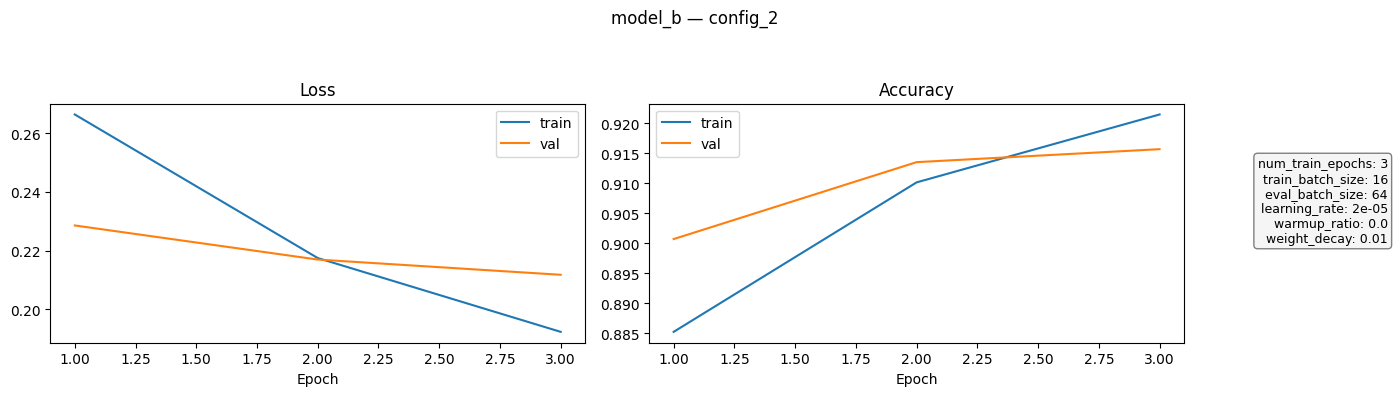

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 36616.05it/s]
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step 0/405 | Loss: 0.6251
Step 50/405 | Loss: 0.2767
Step 100/405 | Loss: 0.2302
Step 150/405 | Loss: 0.3525
Step 200/405 | Loss: 0.2016
Step 250/405 | Loss: 0.3442
Step 300/405 | Loss: 0.3281
Step 350/405 | Loss: 0.3313
Step 400/405 | Loss: 0.2666
Epoch 1/3 | train_loss=0.2914 | train_acc=0.8789 | val_loss=0.2292 | val_acc=0.9013
Step 0/405 | Loss: 0.1650
Step 50/405 | Loss: 0.1324
Step 100/405 | Loss: 0.1985
Step 150/405 | Loss: 0.2049
Step 200/405 | Loss: 0.1744
Step 250/405 | Loss: 0.3637
Step 300/405 | Loss: 0.3883
Step 350/405 | Loss: 0.2053
Step 400/405 | Loss: 0.1614
Epoch 2/3 | train_loss=0.2229 | train_acc=0.9064 | val_loss=0.2275 | val_acc=0.9030
Step 0/405 | Loss: 0.2710
Step 50/405 | Loss: 0.3950
Step 100/405 | Loss: 0.1775
Step 150/405 | Loss: 0.1799
Step 200/405 | Loss: 0.2098
Step 250/405 | Loss: 0.0946
Step 300/405 | Loss: 0.2022
Step 350/405 | Loss: 0.1509
Step 400/405 | Loss: 0.1953
Epoch 3/3 | train_loss=0.1999 | train_acc=0.9168 | val_loss=0.2132 | val_acc=0.9160


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.55it/s]


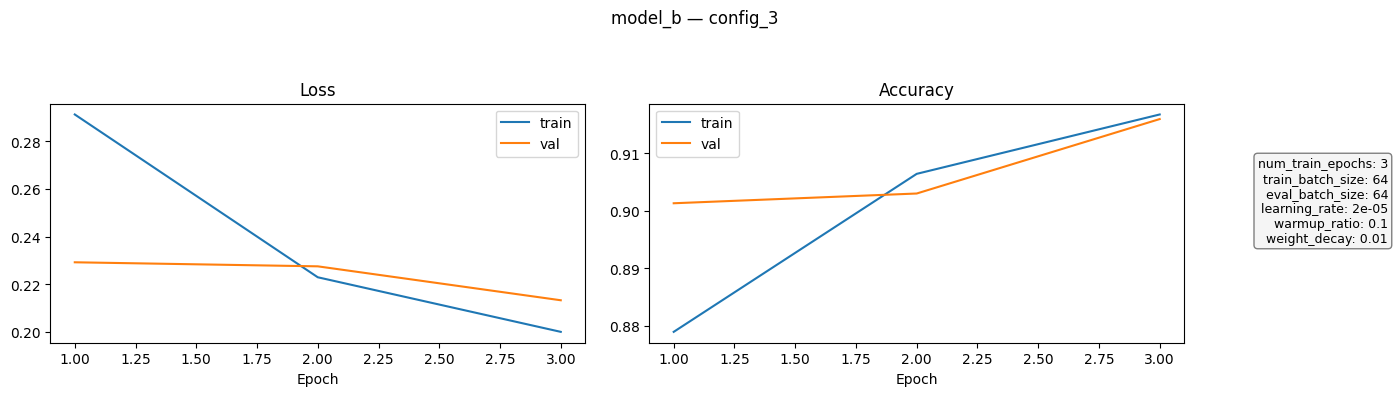


Best config for model_b: config_3 (val_acc=0.9160)


'config_3'

In [ ]:
train_ds_b = TextDataset(train_df_b["text"], train_df_b["label"], tokenizer)
val_ds_b = TextDataset(val_df_b["text"], val_df_b["label"], tokenizer)

train_all_configs("model_b", train_ds_b, val_ds_b)

## ML Baseline: TF-IDF + Logistic Regression

I'm adding a classical machine learning baseline: TF-IDF(Term Frequency–Inverse Document Frequency) + Logistic Regression. Got some help from [here](https://medium.com/@ryblovartem/text-classification-baseline-with-tf-idf-and-logistic-regression-2591fe162f3b) to choose the baseline, and hyperparameters.

I was hoping this simple baseline and the comparison of its performance with the roberta-base model could help me understand how much is the improvement of training/fine-tuning a language model over using a simple ML approach in classifying ai-generated posts. Also, I wanted to do the same conditioning on the baseline to see whether or not the difference between model a and model b is the same as the difference between conditioned and unconditioned logistic regression models.

I didn't really do hyperparameter tuning in this one so the validation set is not used here, but I kept the same validation and test set as the ones I used for finetuning roberta models to stay consistant.

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


def train_tfidf(train_texts, val_texts, test_texts, labels_train, labels_val, labels_test, out_dir):
    """
    Train a TF-IDF + Logistic Regression baseline and save validation/test outputs.

    Inputs:
        train_texts (list[str]): Training text samples.
        val_texts (list[str]): Validation text samples.
        test_texts (list[str]): Test text samples.
        labels_train (list[int] | np.ndarray): Training labels (0/1).
        labels_val (list[int] | np.ndarray): Validation labels (0/1).
        labels_test (list[int] | np.ndarray): Test labels (0/1).
        out_dir (str): Directory path where .npy outputs are saved.

    Outputs:
        Pipeline: Fitted sklearn pipeline with:
            - "tfidf" (TfidfVectorizer)
            - "clf" (LogisticRegression)
    """
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, sublinear_tf=True)), #transforms raw text strings into sparse TF-IDF feature matrices
        ("clf", LogisticRegression(max_iter=1000)),#takes those feature matrices and learns a binary classifier
    ])
    # the vectorizer is fit and transforms the training data, then the classifier is trained on the resulting feature
    pipe.fit(train_texts, labels_train)

    for split, texts, labels in [
        ("val", val_texts, labels_val),
        ("test", test_texts, labels_test),
    ]:
        # uses the same vocabulary and IDF weights that were learned during training to new text before passing it through the classifier
        proba = pipe.predict_proba(texts)
        np.save(f"{out_dir}/{split}_logits.npy", np.log(proba + 1e-9))
        np.save(f"{out_dir}/{split}_labels.npy", np.array(labels))

    return pipe


def prepend_platform(df):
    """
    Prepend platform token to each text in a dataframe.

    Inputs:
        df (pd.DataFrame): DataFrame containing at least:
            - "source" (str): Platform name
            - "text" (str): Original text content

    Outputs:
        list[str]: Texts formatted as:
            "[PLATFORM: {source}] {text}"
    """
    return df.apply(lambda r: f"[PLATFORM: {r['source']}] {r['text']}", axis=1).tolist()


tfidf_baseline = train_tfidf(
    train_df["text"].tolist(), val_df["text"].tolist(), test_df["text"].tolist(),
    train_df["label"].tolist(), val_df["label"].tolist(), test_df["label"].tolist(),
    f"{path}/checkpoints/tfidf_baseline",
)

tfidf_platform = train_tfidf(
    prepend_platform(train_df), prepend_platform(val_df), prepend_platform(test_df),
    train_df["label"].tolist(), val_df["label"].tolist(), test_df["label"].tolist(),
    f"{path}/checkpoints/tfidf_platform",
)